## Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\symbi\Downloads\car_age_price.csv")

In [3]:
data.head()

,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


In [4]:
data.shape

(112, 2)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    112 non-null    int64
 1   Price   112 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB


In [6]:
data.isnull().sum()

Year     0
Price    0
dtype: int64

In [7]:
data.describe()

,Year,Price
count,112.000000,112.000000
mean,2016.669643,483866.044643
std,1.629616,91217.450533
min,2013.000000,300000.000000
25%,2015.000000,423750.000000
50%,2017.000000,500000.000000
75%,2017.000000,550000.000000
max,2020.000000,755000.000000


In [8]:
data.duplicated().sum()

np.int64(54)

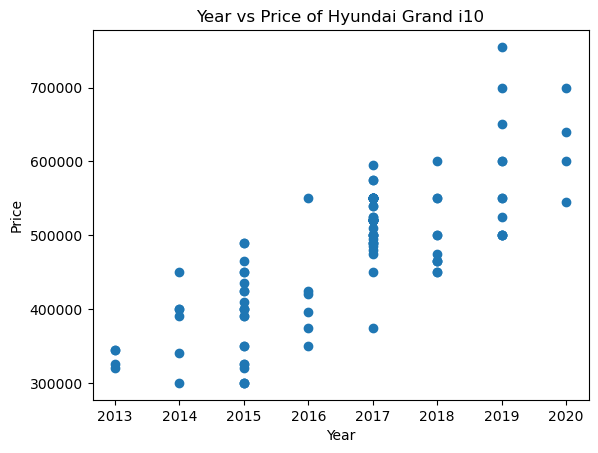

In [9]:
plt.scatter(data['Year'], data['Price'])

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Year vs Price of Hyundai Grand i10')

plt.show()

In [12]:
data['Year'].corr(data['Price'])

np.float64(0.776302138641932)

In [13]:
x = data[['Year']]
y = data['Price']

In [14]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state = 42)

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
linear_model = LinearRegression()

In [19]:
linear_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = linear_model.predict(x_test)

In [22]:
y_pred

array([600775.91252081, 505558.77690466, 553167.34471273, 553167.34471273,
       553167.34471273, 410341.6412885 , 505558.77690466, 553167.34471273,
       600775.91252081, 600775.91252081, 315124.50567235, 505558.77690466,
       410341.6412885 , 648384.48032889, 553167.34471273, 600775.91252081,
       315124.50567235, 410341.6412885 , 505558.77690466, 505558.77690466,
       505558.77690466, 505558.77690466, 505558.77690466])

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [28]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 53534.77957001264
MSE : 4326906256.829671
RMSE: 65779.22359552195
R2 Score: 0.36759313425902185


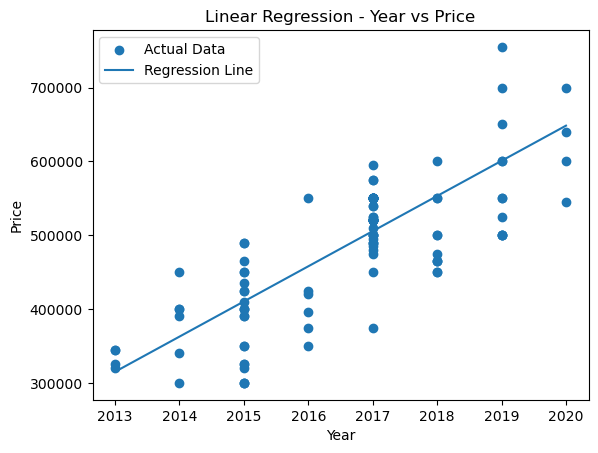

In [30]:
x_sorted = x.sort_values('Year')

y_line = linear_model.predict(x_sorted)

plt.scatter(data['Year'], data['Price'], label='Actual Data')

plt.plot(
    x_sorted['Year'],
    y_line,
    label='Regression Line'
)

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Linear Regression - Year vs Price')
plt.legend()

plt.show()

In [31]:
car_2022 = pd.DataFrame({
    'Year': [2022]
})

In [32]:
predicted_price_2022 = linear_model.predict(car_2022)

print("Predicted price of 2022 model:", predicted_price_2022[0])

Predicted price of 2022 model: 743601.6159450412


## Lasso Regression

In [33]:
from sklearn.linear_model import Lasso

In [34]:
lasso_model = Lasso(alpha=1.0)

In [35]:
lasso_model.fit(x_train, y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [36]:
y_pred_lasso = lasso_model.predict(x_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, y_pred_lasso)

In [39]:
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R2 Score:", lasso_r2)

MAE : 53534.33030898286
MSE : 4326859771.015669
RMSE: 65778.8702473345
R2 Score: 0.3675999284778446


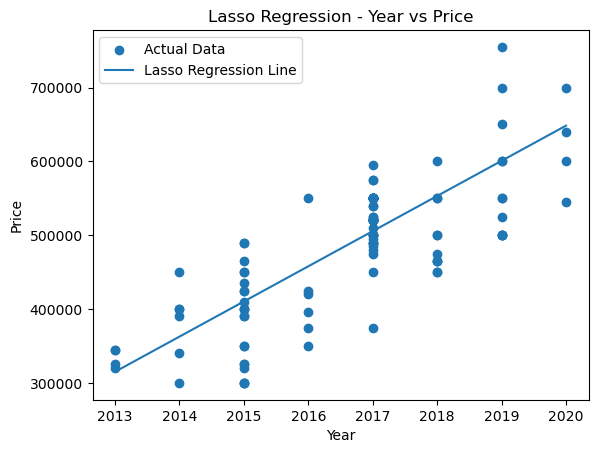

In [41]:
x_sorted = x.sort_values('Year')

y_lasso_line = lasso_model.predict(x_sorted)

plt.scatter(data['Year'], data['Price'], label='Actual Data')

plt.plot(
    x_sorted['Year'],
    y_lasso_line,
    label='Lasso Regression Line'
)

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Lasso Regression - Year vs Price')
plt.legend()

plt.show()

In [42]:
car_2022 = pd.DataFrame({
    'Year': [2022]
})

In [43]:
lasso_2022 = lasso_model.predict(car_2022)

print("Predicted price of 2022 model:", lasso_2022[0])

Predicted price of 2022 model: 743599.3742714375


## comparison between Linear Regression and Lasso Regression

In [44]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression'],
    'MAE': [mae, lasso_mae],
    'MSE': [mse, lasso_mse],
    'RMSE': [rmse, lasso_rmse],
    'R2 Score': [r2, lasso_r2]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,53534.779570,4.326906e+09,65779.223596,0.367593
1,Lasso Regression,53534.330309,4.326860e+09,65778.870247,0.367600


### Linear Regression and Lasso Regression were applied to predict the price of a second-hand Hyundai Grand i10 based on its year of manufacture. Both models showed nearly identical performance. Linear Regression obtained an R² score of approximately 0.3676 and an RMSE of ₹65,779, while Lasso Regression produced almost the same results with a marginally higher R² and slightly lower RMSE. Therefore, Lasso performed marginally better for this train-test split, although the difference between the two models is negligible. Both models predicted the price of a 2022 Grand i10 to be approximately ₹7.44 lakh. Since the available dataset contains cars only up to 2020, the 2022 prediction is an extrapolation and should be interpreted cautiously.